## Heat conduction on a sphere

In [90]:
import matplotlib.pyplot as plt
import numpy as np

In [91]:
from Theta_Solver import SphericalHeatCondSolver

In [92]:
1.0 / (2* (20-1)**2)

0.0013850415512465374

## 1. Compare the three methods

Baseline parameters:
- N= 10
- dt = 0.001
- t_end = 1.0

Starting with:
- omega = 10.0
- Bi = 1.0

### Time evolution at the surface: u(1, t)

In [87]:
1.0//(50**2)

0.0

In [88]:
theta_values = [0.0, 0.5, 1.0]
N= 18

## Testing Step size

### All $\vartheta$, stabiility

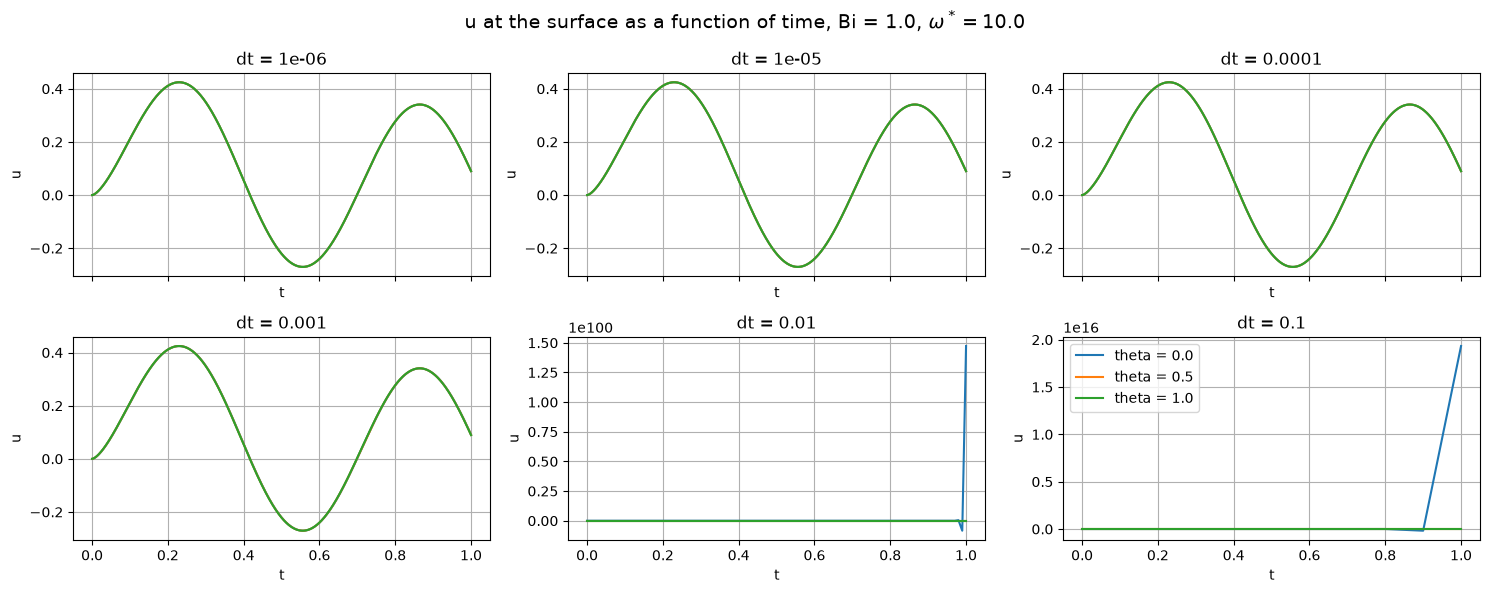

In [120]:
# stability : dt <= dx^2
Bi = 1.0
omega = 10.0
dt_values = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 0.1]
t_end = 1.0

fig, axes = plt.subplots(2, 3, figsize=(15, 6), sharex=True)
axes = axes.ravel()
for theta in [0.0, 0.5, 1.0]:
    for k, dt in enumerate(dt_values):
        ax = axes[k]
        solver = SphericalHeatCondSolver(N, dt, Bi, omega, theta, t_end)
        times, r, U = solver.solve()
    
        ax.plot(times, U[:, -1], label=f"theta = {theta}")
        ax.set_title(fr"dt = {dt}")
        ax.set_xlabel("t")
        ax.set_ylabel("u")
        ax.grid(True)

fig.suptitle(
    fr"u at the surface as a function of time, Bi = {Bi}, $\omega^* = {omega}$",
    fontsize=14
)
plt.legend()
plt.tight_layout()
plt.show()

Instability of the explicit euler method if $\Delta t$ becomes too large

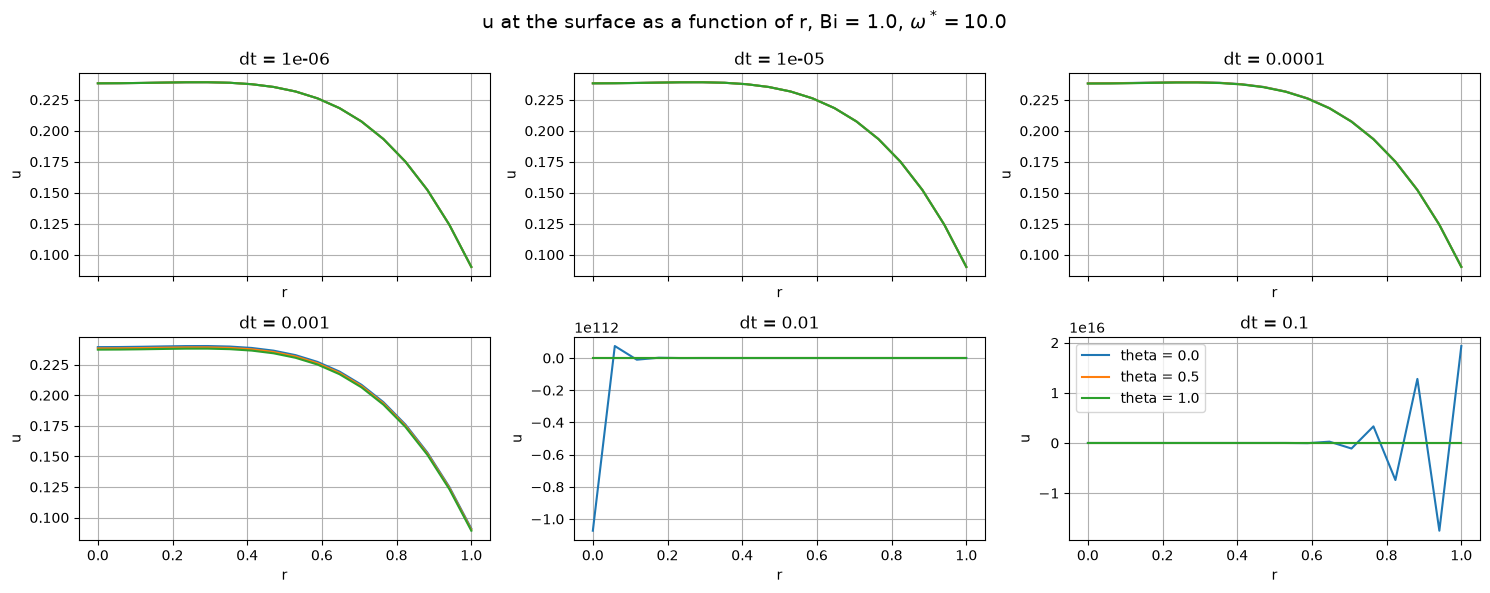

In [59]:
# stability : dt <= dx^2
Bi = 1.0
omega = 10.0
dt_values = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 0.1]
t_end = 1.0

fig, axes = plt.subplots(2, 3, figsize=(15, 6), sharex=True)
axes = axes.ravel()
for theta in [0.0, 0.5, 1.0]:
    for k, dt in enumerate(dt_values):
        ax = axes[k]
        solver = SphericalHeatCondSolver(N, dt, Bi, omega, theta, t_end)
        times, r, U = solver.solve()
    
        ax.plot(r, U[-1, :], label=f"theta = {theta}")
        ax.set_title(fr"dt = {dt}")
        ax.set_xlabel("r")
        ax.set_ylabel("u")
        ax.grid(True)

fig.suptitle(
    fr"u at the surface as a function of r, Bi = {Bi}, $\omega^* = {omega}$",
    fontsize=14
)
plt.legend()
plt.tight_layout()
plt.show()

### Test unconditionally stable methods

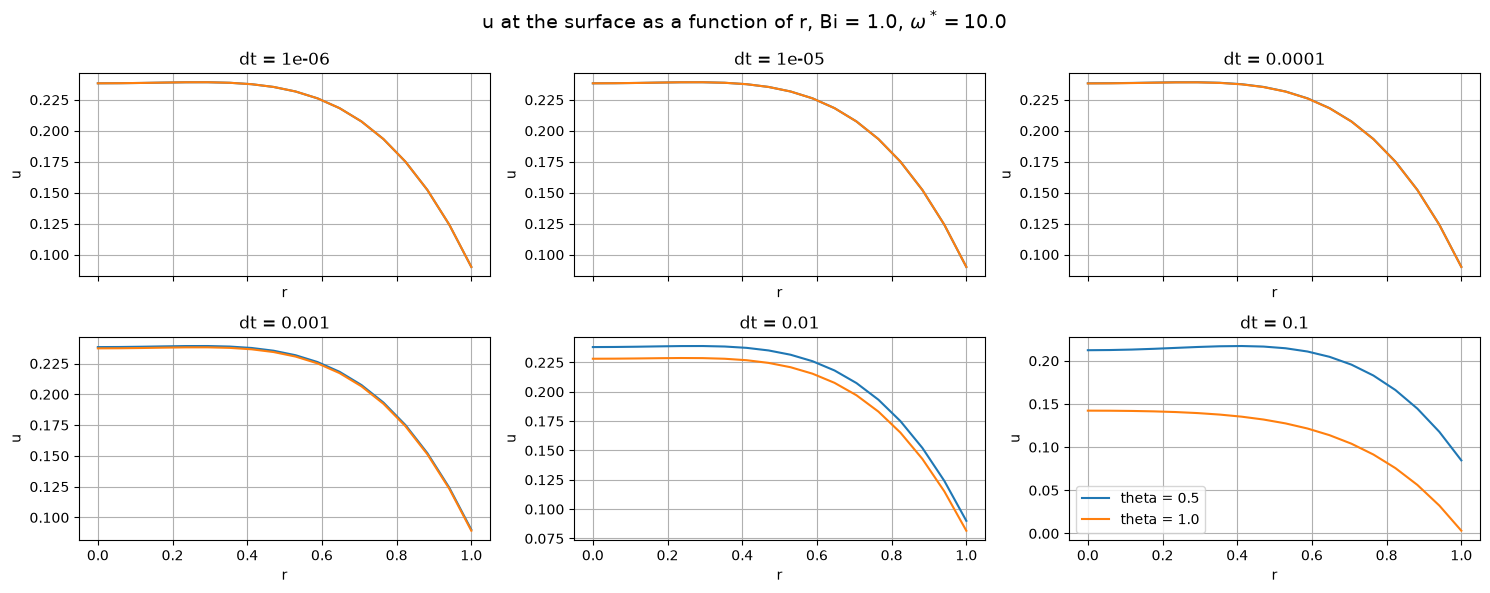

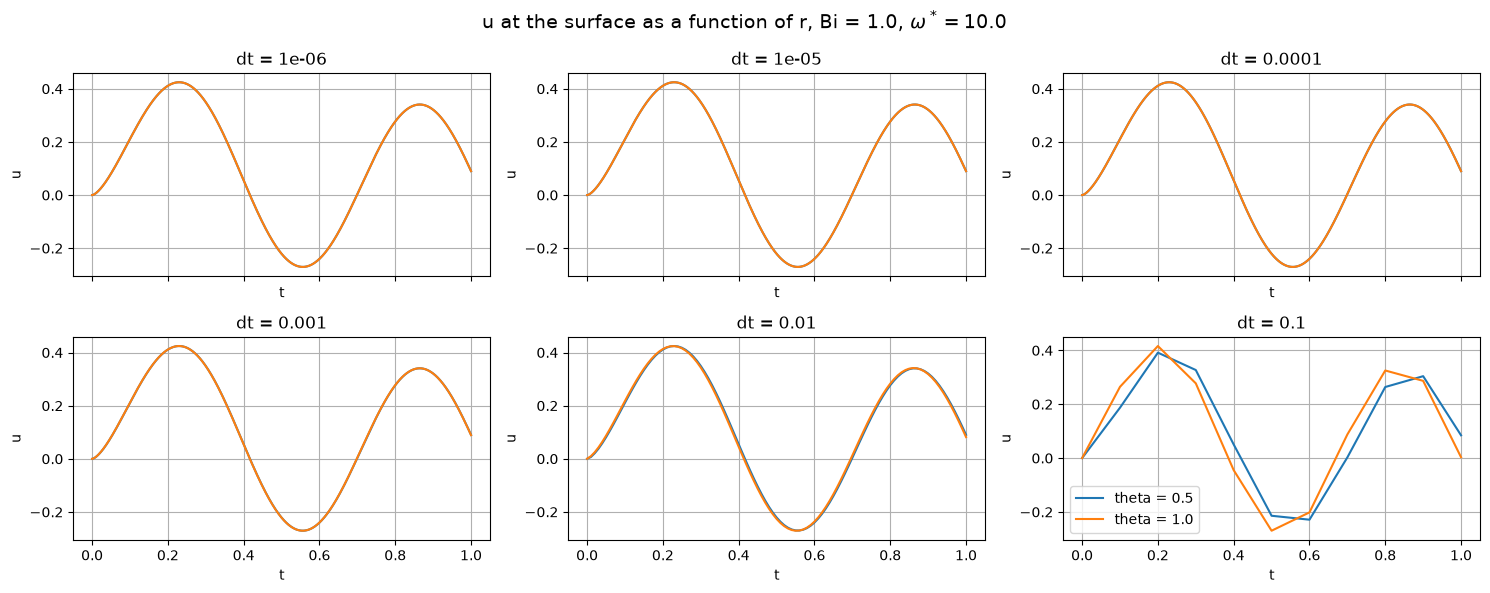

In [ ]:
Bi = 1.0
omega = 10.0
dt_values = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 0.1]
t_end = 1.0

fig, axes = plt.subplots(2, 3, figsize=(15, 6), sharex=True)
axes = axes.ravel()
for theta in [0.5, 1.0]:
    for k, dt in enumerate(dt_values):
        ax = axes[k]
        solver = SphericalHeatCondSolver(N, dt, Bi, omega, theta, t_end)
        times, r, U = solver.solve()
    
        ax.plot(r, U[-1, :], label=f"theta = {theta}")
        ax.set_title(fr"dt = {dt}")
        ax.set_xlabel("r")
        ax.set_ylabel("u")
        ax.grid(True)

fig.suptitle(
    fr"u at the surface as a function of t, Bi = {Bi}, $\omega^* = {omega}$",
    fontsize=14
)
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------

Bi = 1.0
omega = 10.0
dt_values = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 0.1]
t_end = 1.0

fig, axes = plt.subplots(2, 3, figsize=(15, 6), sharex=True)
axes = axes.ravel()
for theta in [0.5, 1.0]:
    for k, dt in enumerate(dt_values):
        ax = axes[k]
        solver = SphericalHeatCondSolver(N, dt, Bi, omega, theta, t_end)
        times, r, U = solver.solve()
    
        ax.plot(times, U[:, -1], label=f"theta = {theta}")
        ax.set_title(fr"dt = {dt}")
        ax.set_xlabel("t")
        ax.set_ylabel("u")
        ax.grid(True)

fig.suptitle(
    fr"u at the surface as a function of r, Bi = {Bi}, $\omega^* = {omega}$",
    fontsize=14
)
plt.legend()
plt.tight_layout()
plt.show()

finer step size: indistinguishable behavior.

Less steps, larger step size:
- implicit euler computes lower temperature values than the trapezoidal at every position in the sphere.
- Good approximation of the evolution of temperature at the boundary in time across the two methods.

### a. Any $\vartheta$, how does $u(r=r^*, t)$ change depending on distance from the surface?

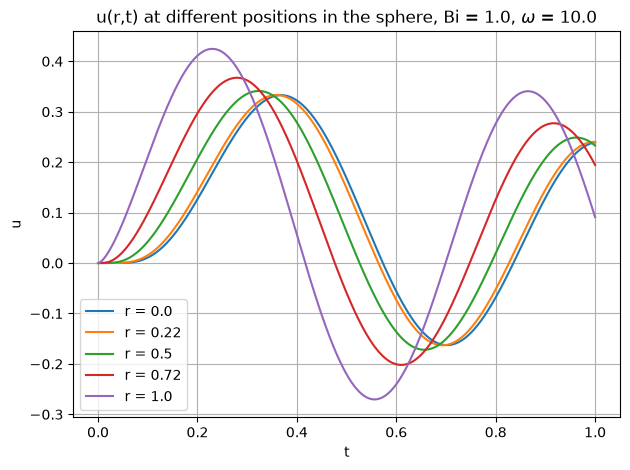

In [36]:
N = 18
Bi = 1.0
omega = 10.0
dt = 0.001
t_end = 1.0

r_dict= {0:0.0, 4:0.22, 9:0.5, 13:0.72, -1:1.0}

for r_idx, r_value in r_dict.items():
    solver = SphericalHeatCondSolver(N, dt, Bi, omega, theta= 0.0, t_end=t_end)
    times, r, U = solver.solve()

    plt.plot(times, U[:, r_idx], label= fr"r = {r_value}")
    
plt.xlabel("t")
plt.ylabel("u")
plt.grid(True)
plt.legend()
plt.title(fr"u(r,t) at different positions in the sphere, Bi = {Bi}, $\omega$ = {omega}")
plt.tight_layout()
plt.show()

- higher amplitude at the surface, lower at the center
- same oscillating pattern across all radiuses, but u decreases in time while it is oscillating
- but time shift: delayed effect at points closer to the center

### $\omega$ and $r$:

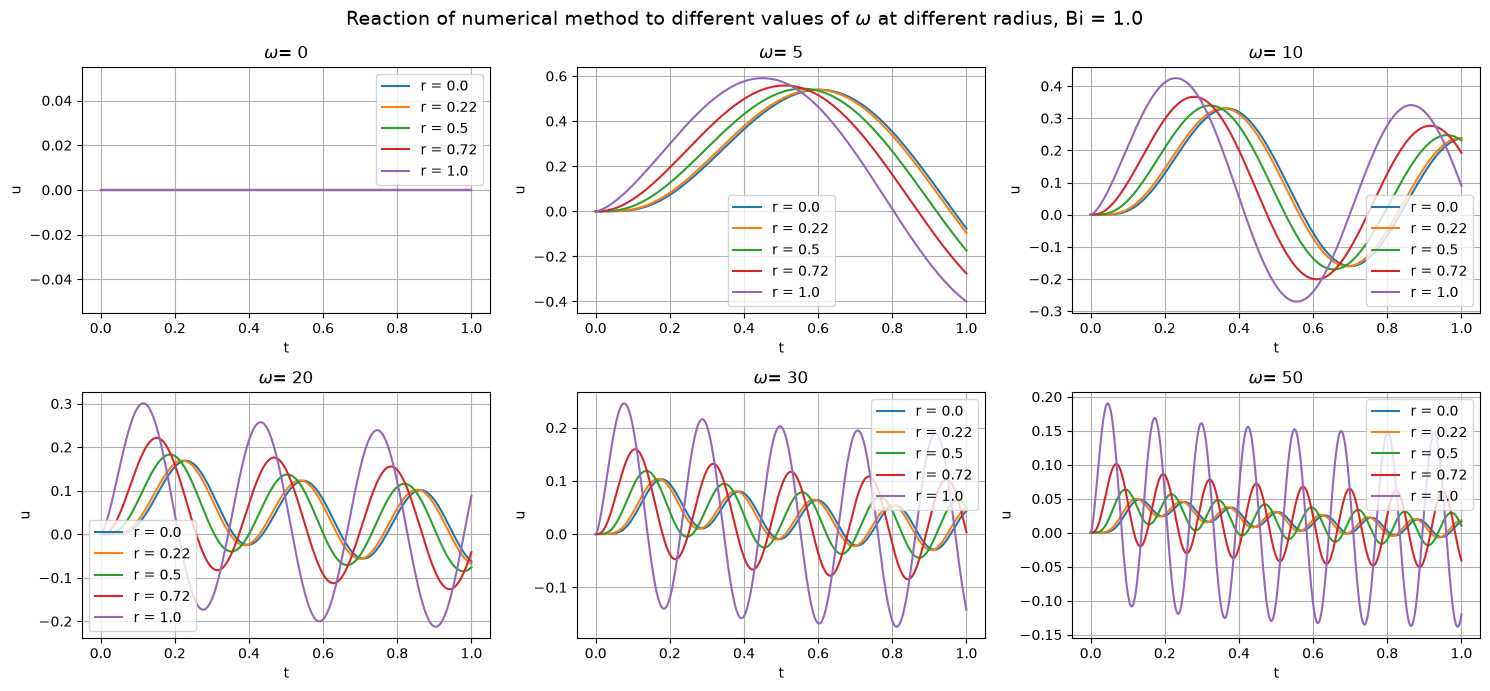

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.ravel()

r_dict= {0:0.0, 4:0.22, 9:0.5, 13:0.72, -1:1.0}

for idx, radius in r_dict.items():
    for k, omega in enumerate(omega_values):
        solver = SphericalHeatCondSolver(N, dt, Bi, omega, theta= theta, t_end=t_end)
        times, r, U = solver.solve()

        ax = axes[k]
        ax.plot(times, U[:, idx], label= fr"r = {radius}")
        ax.set_title(fr"$\omega$= {omega}")
        #ax.set_title(f"$u(r,t)$")
        ax.set_xlabel("t")
        ax.set_ylabel("u")
        ax.grid(True)
        ax.legend()

fig.suptitle(
    fr"Reaction of numerical method to different values of $\omega$ at different radius, Bi = {Bi}",
    fontsize=14
)

plt.tight_layout()
plt.show()

higher values of $\omega$ are reflected in change of oscillating pattern in time. higher frequency leads to lower amplitude and faster oscillating patterns. the delay between $u$ at different radius is scaled but preserved.

### b. Test stable $\vartheta$ with different $\omega$ - vs time

### Are numerical methods different at different position?
At fine time step, indistinguishable. Test with coarser step size
- stable methods, large step size, vs time

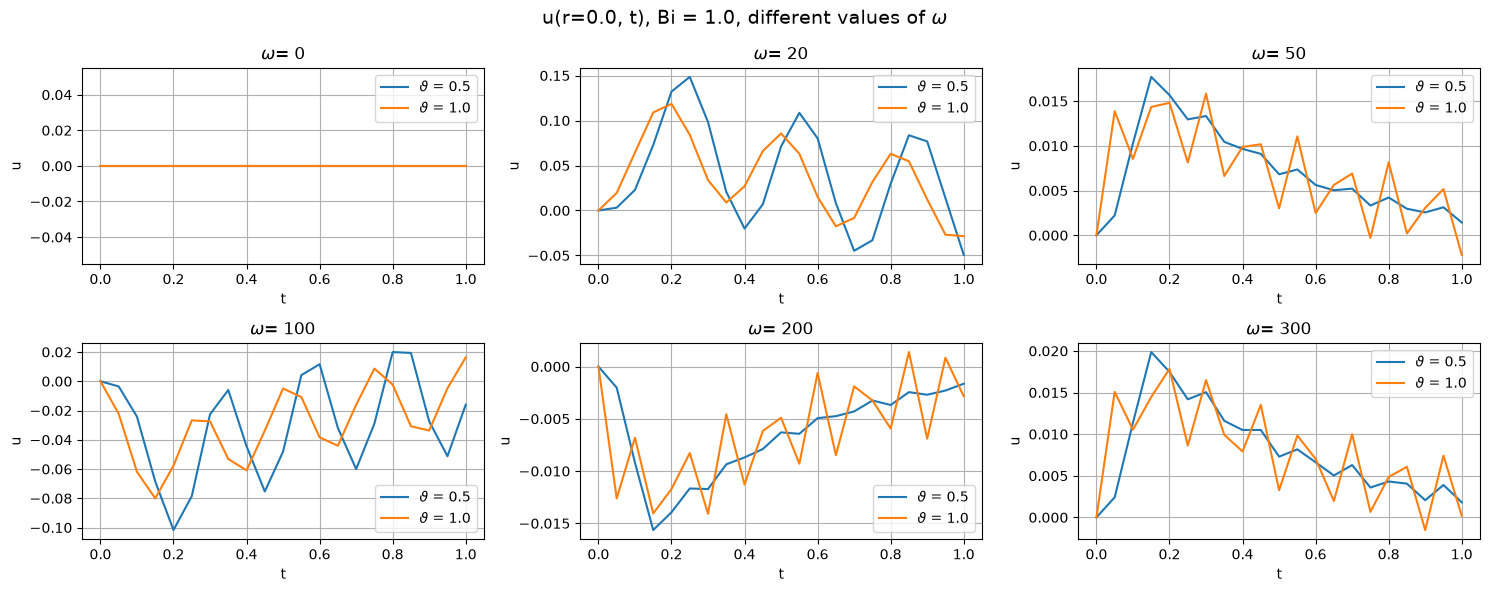

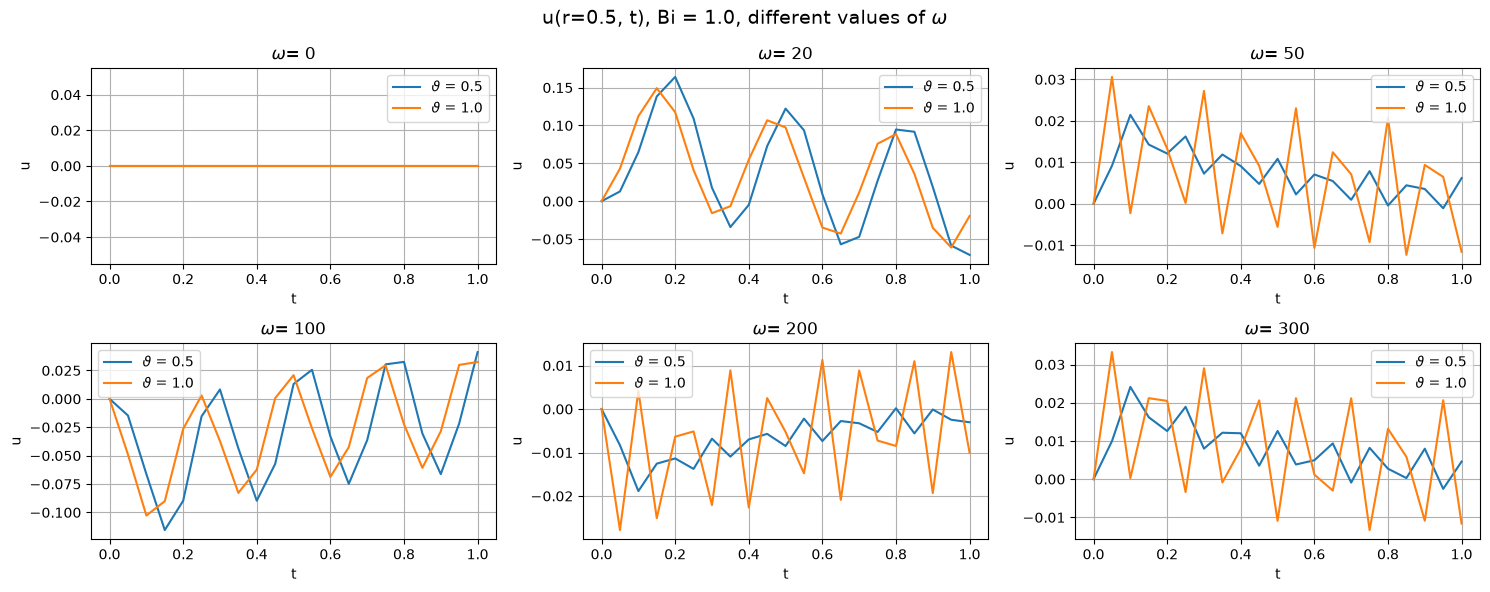

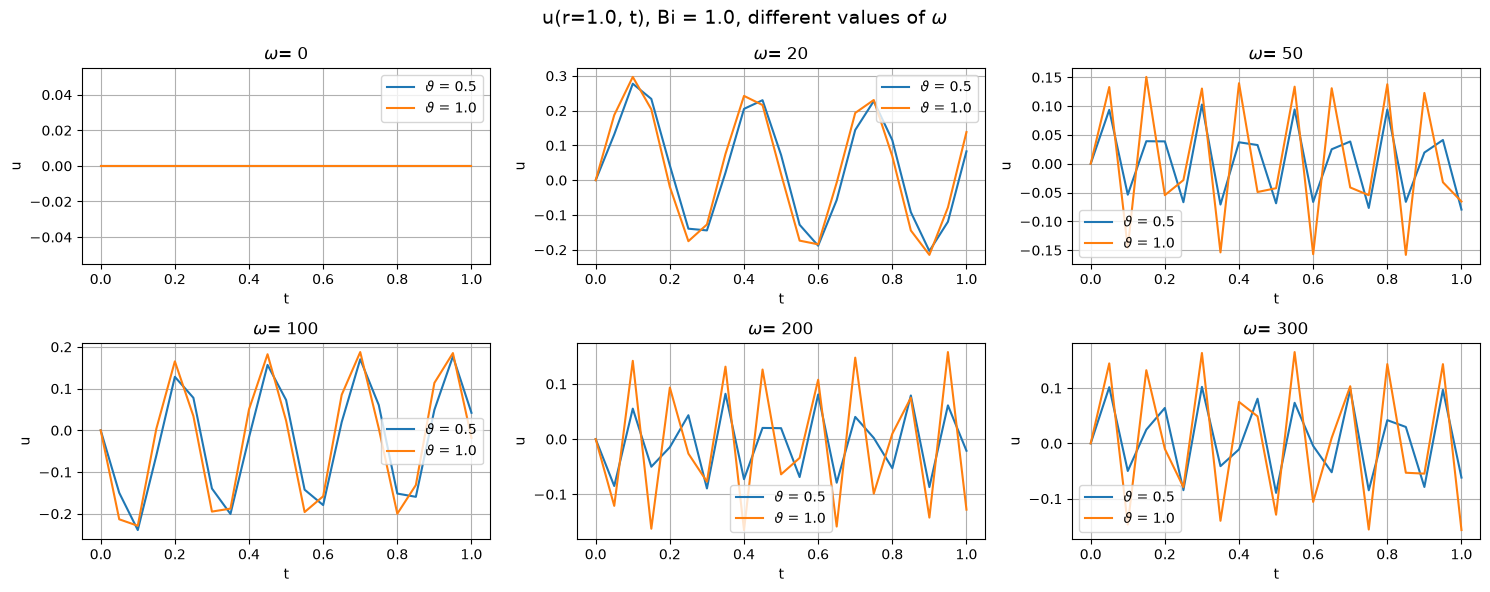

In [107]:
N = 18
Bi = 1.0
dt = 0.05
t_end = 1.0

n_timesteps = int(t_end / dt)

omega_values = [0, 20, 50, 100, 200, 300]
theta_values = [0.0, 0.5, 1.0]
stable_theta_values = [0.5, 1.0]
r_dict = {0:0.0, 9:0.5, -1:1.0}

for r_idx, r_value in r_dict.items():
    fig, axes = plt.subplots(2, 3, figsize=(15, 6))
    axes = axes.ravel()

    for theta in stable_theta_values:
        for k, omega in enumerate(omega_values):
            solver = SphericalHeatCondSolver(N, dt, Bi, omega, theta= theta, t_end=t_end)
            times, r, U = solver.solve()

            ax = axes[k]
            ax.plot(times, U[:, r_idx], label= fr"$\vartheta$ = {theta}")
            ax.set_title(fr"$\omega$= {omega}")
            #ax.set_title(f"$u(r,t)$")
            ax.set_xlabel("t")
            ax.set_ylabel("u")
            ax.grid(True)
            ax.legend()

    fig.suptitle(
        fr"u(r={r_value}, t), Bi = {Bi}, different values of $\omega$",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

$\omega$ controls the temporal oscillation frequency of $u$, so it is expected that at different radiuses in the sphere, the same oscillating pattern emerges.

However, the amplitude and phase of the response depend on the radius. Points closer to the boundary react more directly, while the centre shows a delayed and damped response, especially for larger values of

With a larger grid size, i see that at low frequencies the two methods perform in a similar way, in different possitions inside the sphere. at low frequency values, trapezoidal reaches higher and lowe values than implicit euler, while at higher frequency values, implicit euler method reaches more extreme values than the trapezoidal. this effect is amplified with a larger step size.

In particular, the two methods give much more similar results neat the surface, meaning more aligned oscillations (at high freq, the implicit spikes harder). At the origin or at the middle, there is more mismatch between the curves (impl euler faster in time, trapezoidal comes with a delay). The effect is more and more evident with a larger step size (coarser approx amplifies errors, but at the surface they still almost align).

### b. Test all $\vartheta$ with different $\text{Bi}$

### Are numerical methods different at different position?

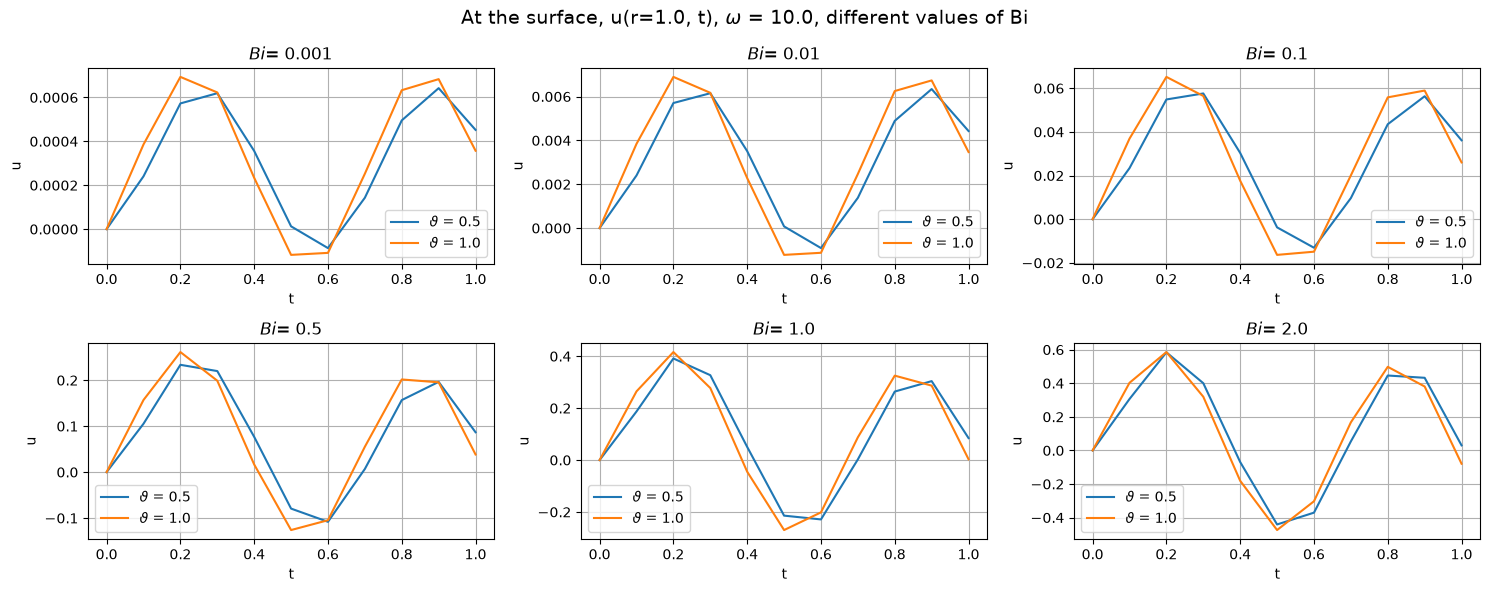

In [112]:
N = 18
omega = 10.0
dt = 0.1
t_end = 1.0

n_timesteps = int(t_end / dt)

Bi_values = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0]
theta_values = [0.5, 1.0]


fig, axes = plt.subplots(2, 3, figsize=(15, 6))
axes = axes.ravel()

for theta in theta_values:
    for k, Bi in enumerate(Bi_values):
        solver = SphericalHeatCondSolver(N, dt, Bi, omega, theta= theta, t_end=t_end)
        times, r, U = solver.solve()

        ax = axes[k]
        ax.plot(times, U[:, -1], label= fr"$\vartheta$ = {theta}")
        ax.set_title(fr"$Bi$= {Bi}")
        #ax.set_title(f"$u(r,t)$")
        ax.set_xlabel("t")
        ax.set_ylabel("u")
        ax.grid(True)
        ax.legend()

fig.suptitle(
    fr"At the surface, u(r=1.0, t), $\omega$ = {omega}, different values of Bi",
    fontsize=14
)

plt.tight_layout()
plt.show()

Even at large step size, the two methods have approx same behavior in response to changes to Biot number.

### $\text{Bi}\leq 10$

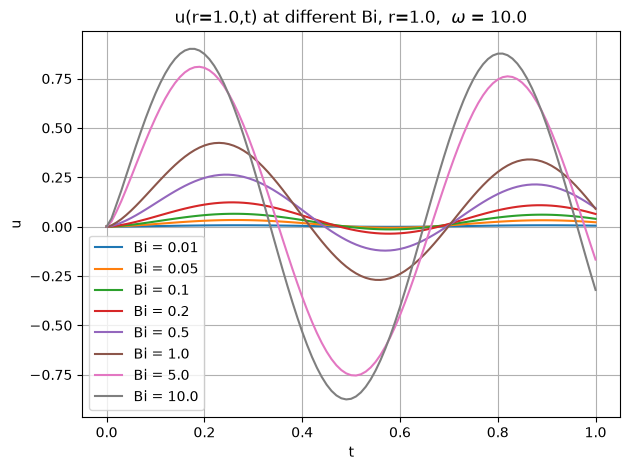

In [116]:
N = 18
omega = 10.0
dt = 0.01
t_end = 1.0

n_timesteps = int(t_end / dt)

Bi_values = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 5.0, 10.0]
for Bi_idx, Bi in enumerate(Bi_values):
    solver = SphericalHeatCondSolver(N, dt, Bi, omega, theta= 0.5, t_end=t_end)
    times, r, U = solver.solve()

    plt.plot(times, U[:, -1], label= fr"Bi = {Bi}")
    
plt.xlabel("t")
plt.ylabel("u")
plt.grid(True)
plt.legend()
plt.title(fr"u(r=1.0,t) at different Bi, r=1.0,  $\omega$ = {omega}")
plt.tight_layout()
plt.show()

- Large Biot number -> oscillations are amplified, so temperature at the surface fluctuates stronger in time.
- Small Biot number: temperature at the surface is almost constant in time.

## Space evolution at different time steps

In [43]:
int(t_end / dt)

1000

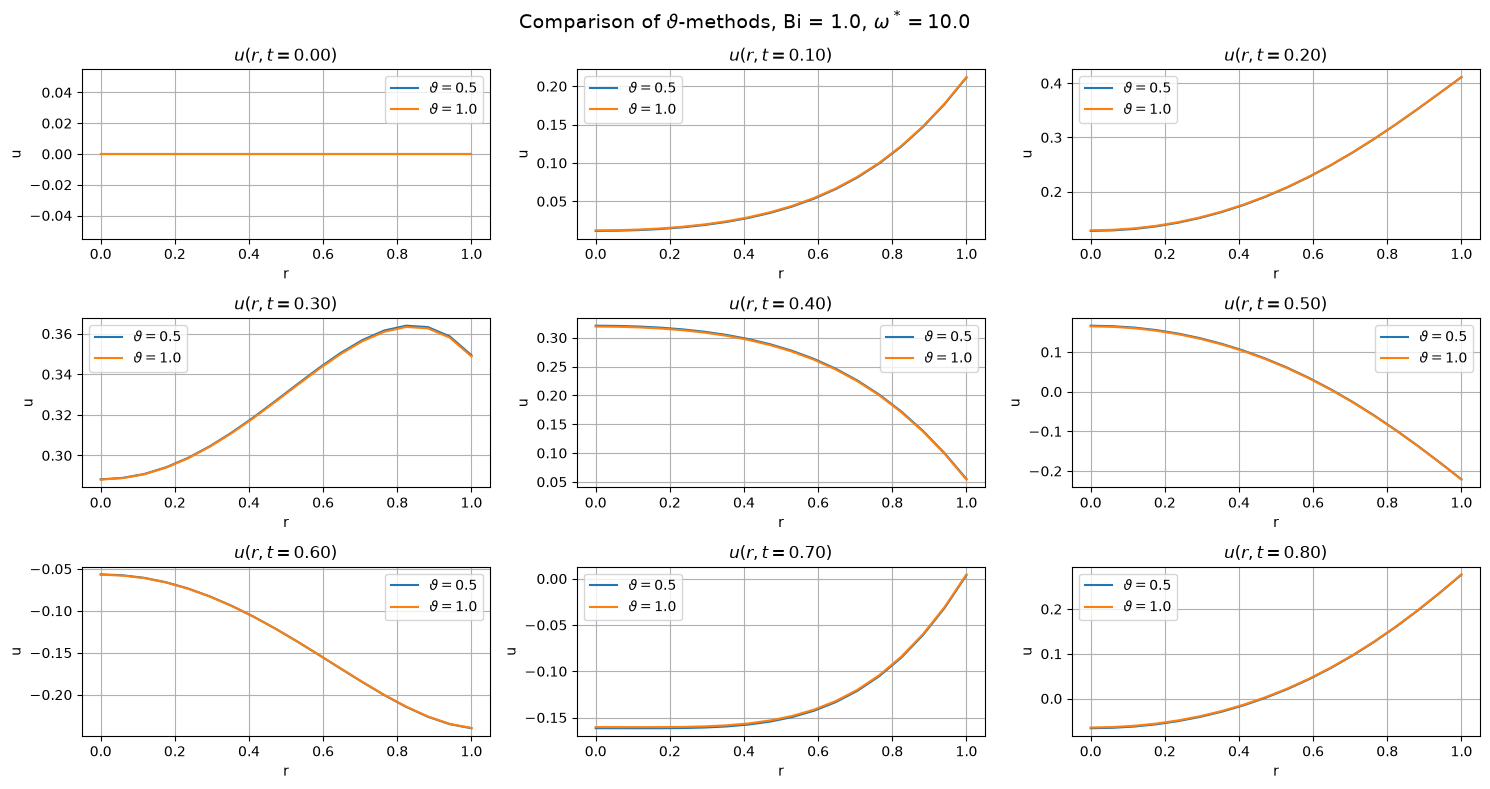

In [123]:
## test many time steps and evaluate u(r, t=tn)
N = 18
Bi = 1.0
omega = 10.0
dt = 0.001
t_end = 1.0

n_timesteps = int(t_end / dt)

time_steps = [0, 100, 200, 300, 400, 500, 600, 700, 800]

fig, axes = plt.subplots(3, 3, figsize=(15, 8))
axes = axes.ravel()

for theta in stable_theta_values:
    solver = SphericalHeatCondSolver(N, dt, Bi, omega, theta, t_end)
    times, r, U = solver.solve()

    for k, idx in enumerate(time_steps):
        ax = axes[k]

        ax.plot(r, U[idx, :], label=fr"$\vartheta = {theta}$")
        ax.set_title(fr"$u(r,t={times[idx]:.2f})$")
        ax.set_xlabel("r")
        ax.set_ylabel("u")
        ax.grid(True)
        ax.legend()

fig.suptitle(
    fr"Comparison of $\vartheta$-methods, Bi = {Bi}, $\omega^* = {omega}$",
    fontsize=14
)

plt.tight_layout()
plt.show()

I watch the solution evolve during the sinusoidal boundary forcing $$\sin(\omega t)$$
So the boundary condition changes sign in time. That is why the profile first positive, then decreasing, then negative, then positive again.
With coarser values of $N$, $dt$, it is possible to see a slight mismatch between the three curves, which is almost imperceptible if the discretization grids are finer. 

### Instability of $\vartheta = 0$

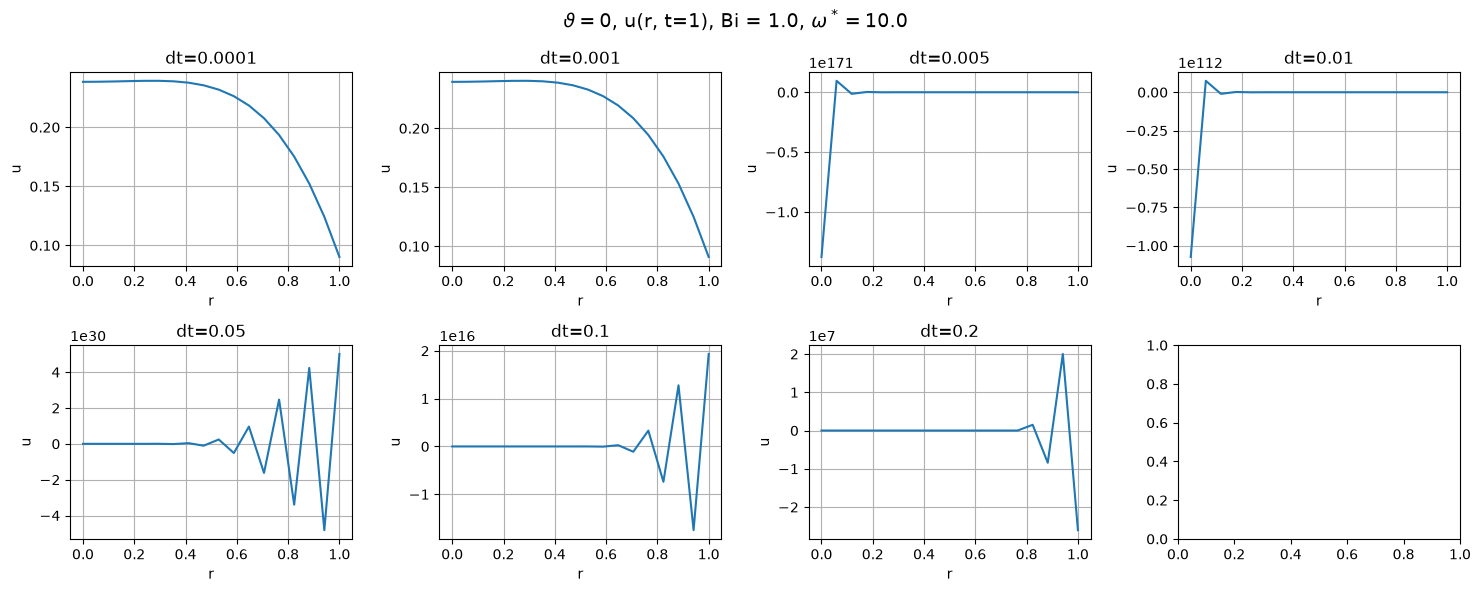

In [131]:
Bi = 1.0
omega = 10.0
#dt = 0.001
t_end = 1.0

n_timesteps = int(t_end / dt)

dt_values = [1e-4, 1e-3, 0.005, 0.01, 0.05, 0.1, 0.2]

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
axes = axes.ravel()

for k, dt in enumerate(dt_values):
    solver = SphericalHeatCondSolver(N, dt, Bi, omega, theta= 0.0, t_end=t_end)
    times, r, U = solver.solve()

    ax = axes[k]
    ax.plot(r, U[-1, :], label=fr"dt = {dt}")
    ax.set_title(f"{dt=}")
    #ax.set_title(f"$u(r,t)$")
    ax.set_xlabel("r")
    ax.set_ylabel("u")
    ax.grid(True)
    #ax.legend()

fig.suptitle(
    fr"$\vartheta=0$, u(r, t=1), Bi = {Bi}, $\omega^* = {omega}$",
    fontsize=14
)

plt.tight_layout()
plt.show()

Explicit Euler condition for stability is $\Delta t \leq \Delta r^2 $, so the time step scales quadratically with the grid step size. Keeping $\Delta r =18$, if $\Delta t$ becomes too large the stability condition is not satisfied.

### Different values of $\omega$:

In [46]:
n_timesteps

1000

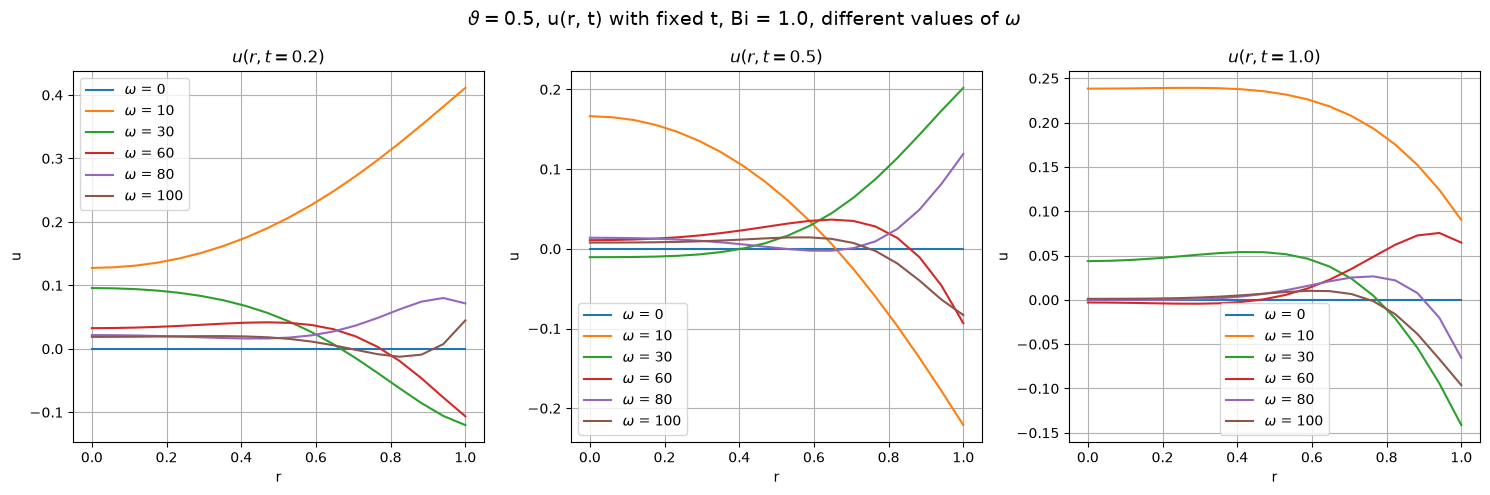

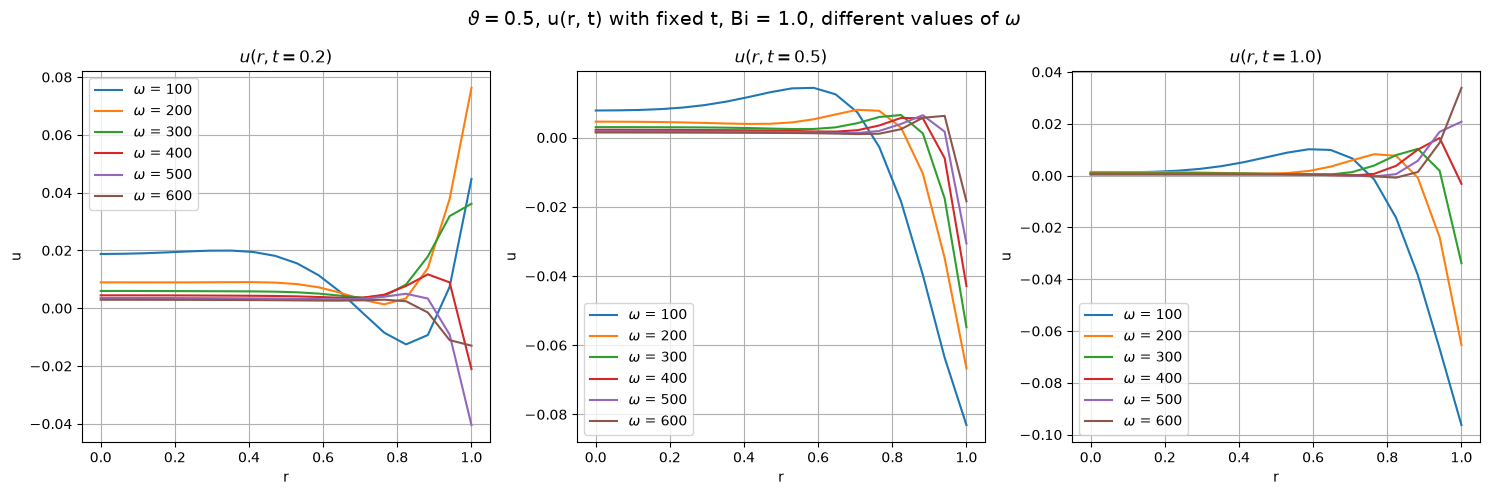

In [49]:
# stable: 
N = 18
Bi = 1.0
dt = 0.001
t_end = 1.0

n_timesteps = int(t_end / dt)

omega_values = [0, 10, 30, 60, 80, 100]
t_values = [0.2, 0.5, 1.0]


fig, axes = plt.subplots(1, len(t_values), figsize=(15, 5))
axes = axes.ravel()

for k, t in enumerate(t_values):
    ax = axes[k]
    for _, omega in enumerate(omega_values):
        solver = SphericalHeatCondSolver(N, dt, Bi, omega, theta= 0.5, t_end=t_end)
        times, r, U = solver.solve()
        
        ax.plot(r, U[int(t*1000), :], label=fr"$\omega$ = {omega}")
        ax.set_title(fr"$\omega$= {omega}")
        ax.set_title(f"$u(r,t = {t})$")
        ax.set_xlabel("r")
        ax.set_ylabel("u")
        ax.grid(True)
        ax.legend()

fig.suptitle(
    fr"$\vartheta=0.5$, u(r, t) with fixed t, Bi = {Bi}, different values of $\omega$",
    fontsize=14
)

plt.tight_layout()
plt.show()





omega_values = [100, 200, 300, 400, 500, 600]
t_values = [0.2, 0.5, 1.0]


fig, axes = plt.subplots(1, len(t_values), figsize=(15, 5))
axes = axes.ravel()

for k, t in enumerate(t_values):
    ax = axes[k]
    for _, omega in enumerate(omega_values):
        solver = SphericalHeatCondSolver(N, dt, Bi, omega, theta= 0.5, t_end=t_end)
        times, r, U = solver.solve()
        
        ax.plot(r, U[int(t*1000), :], label=fr"$\omega$ = {omega}")
        ax.set_title(fr"$\omega$= {omega}")
        ax.set_title(f"$u(r,t = {t})$")
        ax.set_xlabel("r")
        ax.set_ylabel("u")
        ax.grid(True)
        ax.legend()

fig.suptitle(
    fr"$\vartheta=0.5$, u(r, t) with fixed t, Bi = {Bi}, different values of $\omega$",
    fontsize=14
)

plt.tight_layout()
plt.show()



- low frequency: slow oscillations, allow for large differences in temperature across the sphere (the surface is heated / cooled down before and then heat propagates through the sphere, with some delay)

- high frequency: larger omega makes the boundary forcing oscillate faster. The temperature variation is localized near the surface, and the interior of the sphere is less affected by high frequency oscillations. Then the the corresponding temperature oscillations penetrate less deeply into the sphere.

Goes out of range in case of instability

At the final time step, the value of $u$ near the center remains close to $0$ and approx negative at the surface. 
For larger $\omega$, the external forcing $\sin(\omega t)$ oscillates faster. Near the boundary, it spikes and then drops to the final value at the surface. The higher the value of $\omega$, the more peaked the spike is near the surface. So the frequency of oscillations mostly affects the part of the sphere that is closest to the outside convective currents.

Heat diffusion needs time to transport that oscillation into the interior of the sphere. If the boundary oscillates too quickly, the interior cannot follow it well.

### Bi

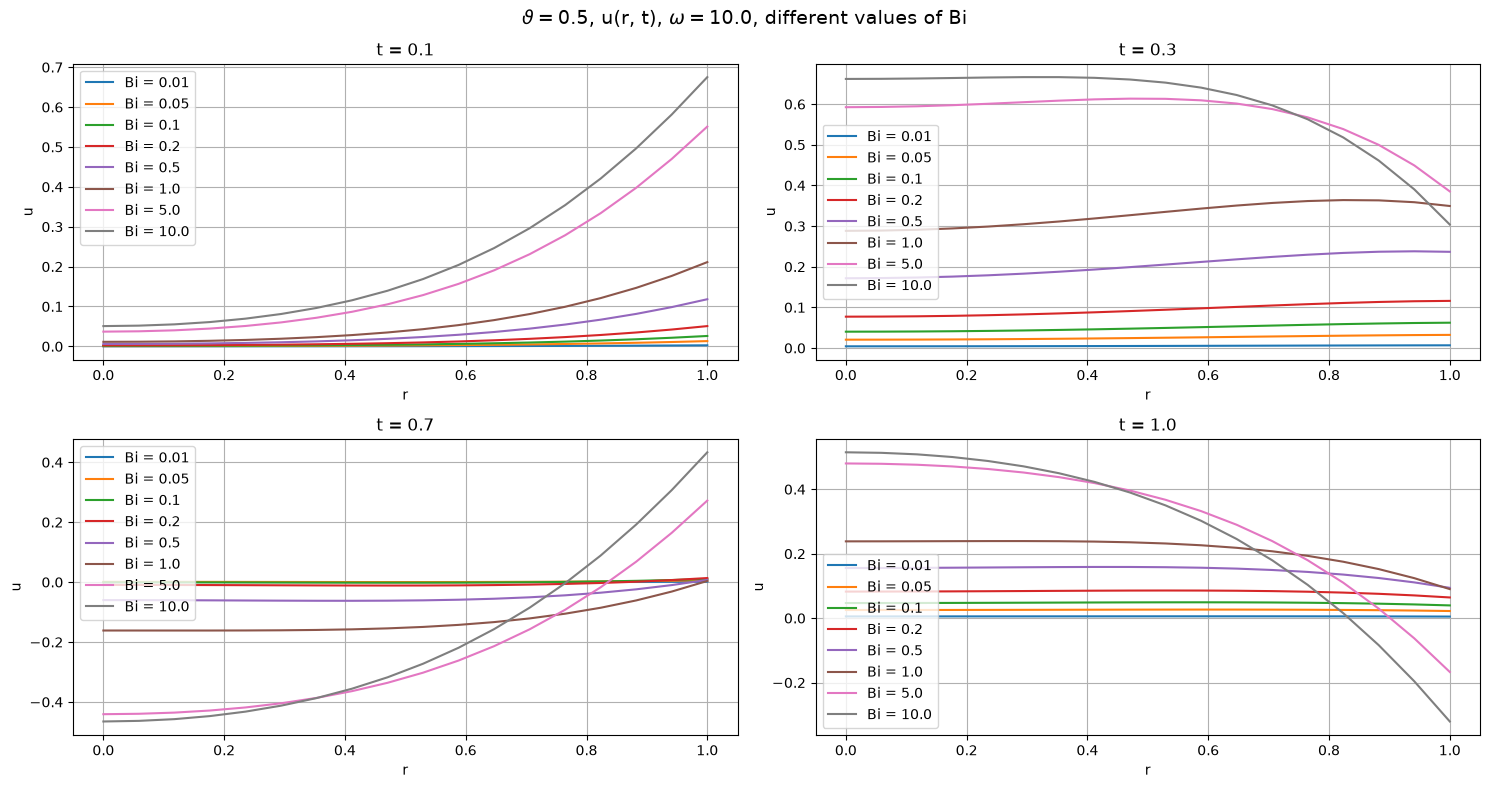

In [ ]:
N = 18
omega = 10.0
dt = 0.001
t_end = 1.0

n_timesteps = int(t_end / dt)

Bi_values = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 5.0]
t_values = [0.1, 0.3, 0.7, 1.0]

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
axes = axes.ravel()

for k, t_val in enumerate(t_values):
    ax = axes[k]
    for Bi in Bi_values:
        solver = SphericalHeatCondSolver(N, dt, Bi, omega, theta= 0.5, t_end=t_end)
        times, r, U = solver.solve()
        idx = np.argmin(np.abs(times - t_val))
        ax.plot(r, U[idx, :], label= fr"Bi = {Bi}")
        ax.set_xlabel("r")
        ax.set_ylabel("u")
        ax.set_title(fr"t = {t_val}")
        ax.grid(True)
        ax.legend()
    

fig.suptitle(
    fr"$\vartheta=0.5$, u(r, t), $\omega= 10.0$, different values of Bi",
    fontsize=14
)
plt.tight_layout()
plt.show()

- $Bi < 0.1:$ Lumped System Analysis. The internal conductive resistance is negligible compared to the surface convective resistance. The sphere heats or cools uniformly, and we can assume the temperature is the same throughout the entire sphere at any given time.

- $Bi ≥ 0.1:$ Internal Temperature Gradients. Internal resistance is significant. The temperature inside the body varies spatially; points closer to the surface heat or cool much faster than points deep in the core.

The pattern of the curves depend on the type of external current in time: since it is oscillating, at time t=0.1 it looks like the outside temperature is larger than the inside, so heat is propagating inwards, while at the end of the simulation the heat flow is reversed, since the inside of the sphere is hotter than the outside.